# Linear Regression

    Occlusion  Accuracy Model_Type
0           0      89.8        CNN
1          25      90.6        CNN
2          50      90.8        CNN
3           0      90.4        CNN
4          25      89.1        CNN
5          50      91.6        CNN
6           0      96.3        VIT
7          25      95.6        VIT
8          50      96.9        VIT
9           0      89.5        VIT
10         25      86.0        VIT
11         50      81.3        VIT
                            OLS Regression Results                            
Dep. Variable:               Accuracy   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                 -0.196
Method:                 Least Squares   F-statistic:                   0.09973
Date:                Tue, 26 Aug 2025   Prob (F-statistic):              0.906
Time:                        21:34:06   Log-Likelihood:                -34.068
No. Observations:                  12   AIC:                           

C:\Users\EuanH\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=12 observations were given.
  return hypotest_fun_in(*args, **kwds)


[Text(0.5, 1.0, 'Model Accuracy Given Occlusion'),
 Text(0, 0.5, 'Accuracy'),
 Text(0.5, 0, 'Occlusion Level (%)')]

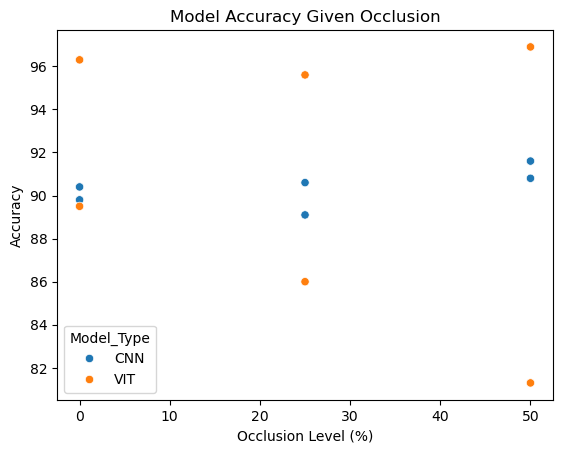

In [10]:
import numpy as np
import pandas
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import seaborn as sns

x = np.array([0, 25, 50, 0, 25, 50, 0, 25, 50, 0, 25, 50])
model_type = np.array(['CNN', 'CNN', 'CNN', 'CNN', 'CNN', 'CNN', 'VIT', 'VIT', 'VIT', 'VIT', 'VIT', 'VIT'])
y_e = np.array([89.8, 90.6, 90.8])
y_r = np.array([90.4, 89.1, 91.6])
y_v = np.array([96.3, 95.6, 96.9])
y_p = np.array([89.5, 86.0, 81.3])

joined_acc = np.concatenate((y_e, y_r, y_v, y_p))
# Add constant for intercept term
X = sm.add_constant(x)

# Fit OLS model
data = pandas.DataFrame({'Occlusion': x, 'Accuracy': joined_acc, 'Model_Type': model_type})

print(data)
model = ols("Accuracy ~ Occlusion + C(Model_Type)", data).fit()
model_2 = ols("Accuracy ~ Occlusion", data).fit()
model_3 = ols("Accuracy ~ C(Model_Type)", data).fit()
anova = anova_lm(model_2, model) # Occlusion
anova_2 = anova_lm(model_3, model) # Model Type
#T_test = model.t_test(r)
#print(r)
print(model.summary())
#print(model_2.summary())
#print(model_3.summary())
print(anova)
print(anova_2)

ax = sns.scatterplot(data=data[["Occlusion", "Accuracy", 'Model_Type']], x="Occlusion", y="Accuracy", hue="Model_Type")
ax.set(title="Model Accuracy Given Occlusion", ylabel="Accuracy", xlabel="Occlusion Level (%)")
#lgd = sns.move_legend(ax, "upper left", bbox_to_anchor=(0.5,1))